# Data preparation and roof label quality

This notebook audits the supplied satellite images before model training. It shows the checks, measured results and image–mask overlays. It does not train a model or alter the source images and labels. Reusable implementation lives in `roof_utils/data_preparation.py`.

**Decision:** quarantine pair `278` from supervised training. Its label is pixel-identical to `270`'s, but the images are different and the mask is visibly misaligned on `278`. Keep both original files for provenance; reinstate the pair only after obtaining a verified correction. The provisional supervised set therefore contains **24 pairs**, plus **five originally unlabelled images** for later prediction. Other pairs still require a human annotation-consistency review.


In [1]:
from pathlib import Path
import sys

# Allow imports when Jupyter starts in notebooks/ without an editable install.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "roof_utils").is_dir() and (p / "pyproject.toml").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from roof_utils.config import load_paths
PATHS = load_paths(PROJECT_ROOT)

from roof_utils.data_preparation import PreparationAudit
audit = PreparationAudit(PATHS)


Raw data: /Users/zkm/Desktop/dida_test_task/data
Prepared output: /Users/zkm/Desktop/dida_test_task/data_preparation_outputs
Label threshold: 128 | Validity: alpha == 255


## 1 Inventory and pairing
Match by filename stem, never by the order returned by a directory listing. Verify that every label has an image, every file is readable, dimensions match, and input modes are understood.


In [2]:
audit.inventory()


Images: 30 | labels: 25 | paired: 25
Unlabelled: 535, 537, 539, 551, 553
Orphan labels: []
Image modes: {'RGBA': 30} | label modes: {'L': 25}
Image dimensions: {'(256, 256)': 30}


## 2 Exact duplicates and the 278 decision
Hash decoded pixels, including mode and shape, rather than PNG file bytes. Two differently encoded files can contain identical pixels. A duplicate label is a flag for inspection, not automatically an error: the visual comparison below determines why this duplicate is problematic.


Exact duplicate images: []
Exact duplicate labels: [['270', '278']]
Confirmed: 270 and 278 have identical label pixels but different image pixels.


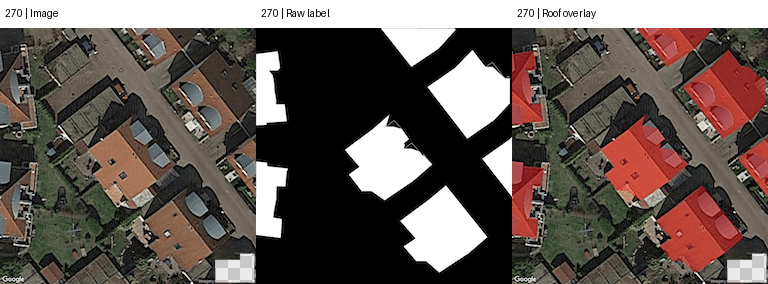

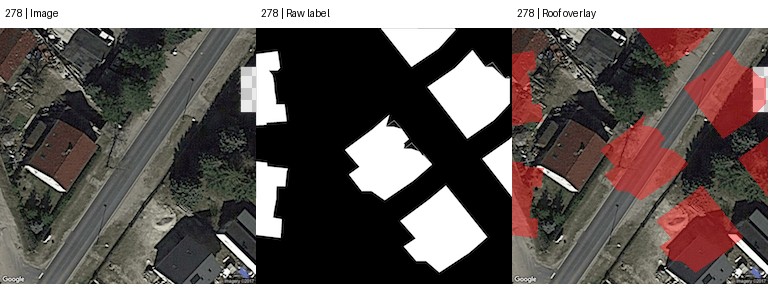

In [3]:
audit.duplicate_review()


**Interpretation:** the duplicated mask follows the roof layout of `270`, while substantial labelled regions lie over the road or other non-roof areas in `278`. This supports quarantining `278` without trying to guess a translation, rotation or replacement label. The exact cause of the duplication is not known. Do not copy a different mask or create a pseudo-label and call it ground truth.

This decision is made from raw data inspection before training or validation results. Keep the image as an unresolved sample, separate from the five originally unlabelled prediction inputs.


## 3 Mask values and transparent regions
Intermediate mask values may arise from antialiasing or resampling, but their origin is not established. The baseline below treats the labels as binary and uses the fixed threshold 128. Inspect the visual effect; `mask > 0` would include low-intensity halos.

Alpha is a validity indicator, not a fourth spectral band. For the baseline, use RGB input, fill non-opaque pixels consistently, and ignore them in loss and metrics. Strict `alpha == 255` also excludes partially transparent edge pixels; this conservative choice is explicit and can be revisited from source-data semantics.


In [4]:
audit.mask_statistics()


All 25 supplied pairs (including quarantined 278):
  Intermediate label pixels: 4.23%
  Roof at >=128, all pixels: 14.55%
  Roof at >0, all pixels: 16.62%
  Fully opaque valid pixels: 93.22%
  Roof among valid pixels: 15.57%
  All-background accuracy over valid pixels: 84.43%
  Roof-labelled pixels excluded by validity: 591

Per-image audit (percentages):
   ID  roof/valid   valid/all   grey mask   alpha=0  partial a
  121       16.84      100.00        5.22      0.00       0.00
  241       15.24       95.55        4.08      3.75       0.69
  270       28.20       98.26        7.76      1.18       0.56
  272       13.50      100.00        4.18      0.00       0.00
  274        5.32      100.00        1.61      0.00       0.00
  278       27.24       98.73        7.76      0.91       0.36
  284       12.75      100.00        4.43      0.00       0.00
  287       20.94       93.51        5.92      5.20       1.29
  300       10.70       95.54        3.20      3.80       0.67
  301       

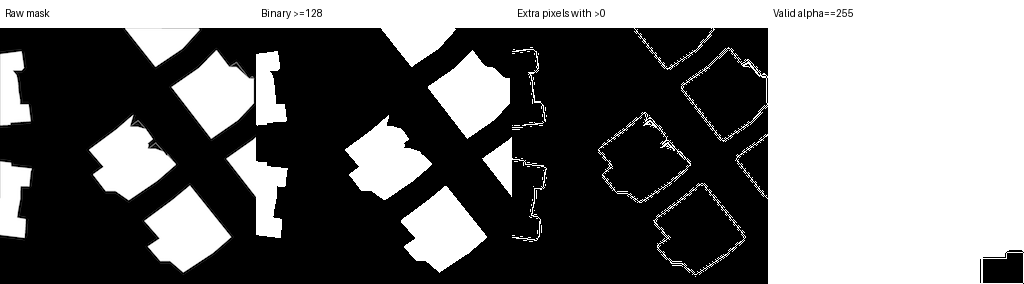

In [5]:
audit.mask_comparison()


## 4 Visual review of every labelled pair
Red denotes the thresholded roof target. Checkerboard denotes transparency. Inspect all panels for image–label registration and the treatment of garages, small buildings, partial roofs at tile borders, and tree occlusion. These are inspection aids, not proof that all annotations are correct.

The audit identifies `278` as a clear issue. All other pairs are provisionally retained. Visually similar or overlapping scenes must be grouped before cross-validation; the absence of exact duplicates does not establish geographical independence. Source coordinates or a manual overlap review are needed to resolve that question.


Pairs: 121, 241, 270, 272, 274


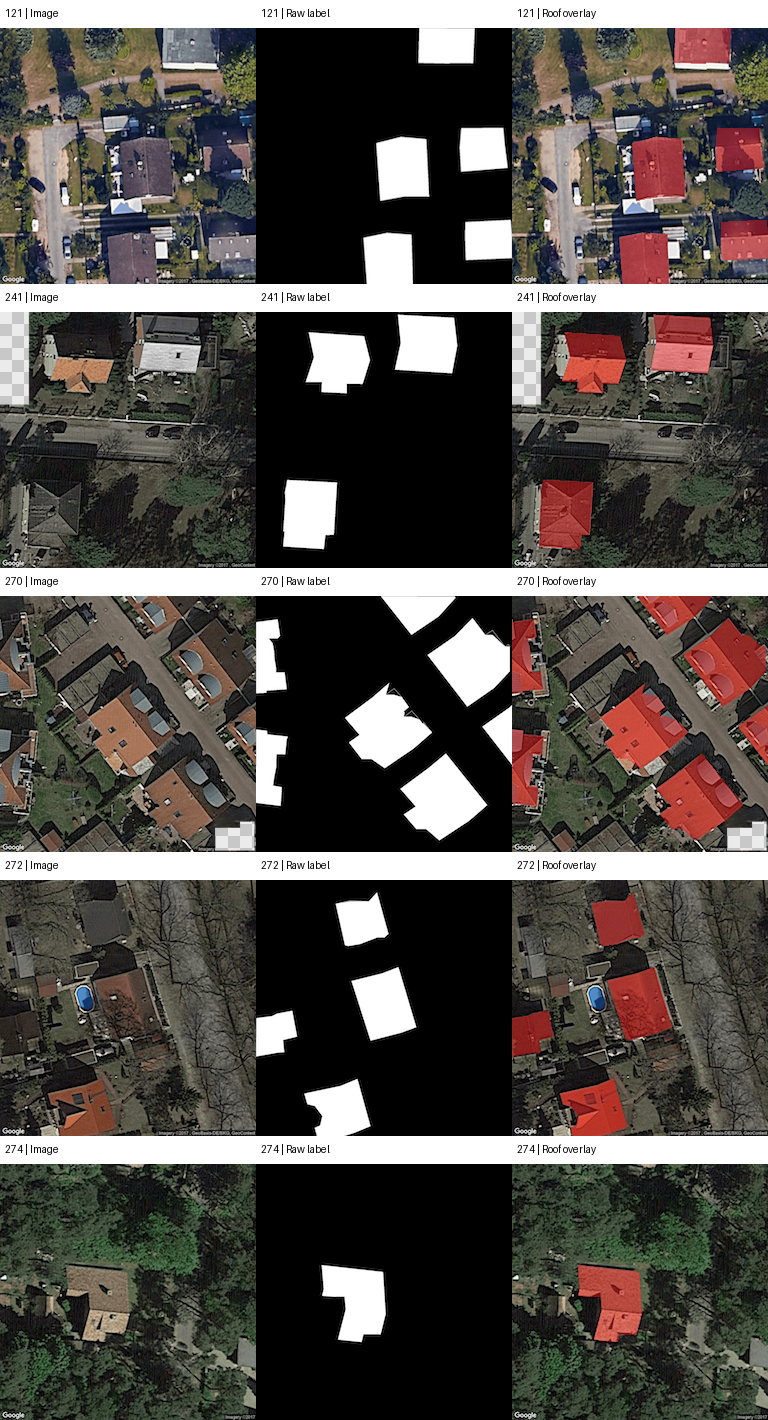

Pairs: 278, 284, 287, 300, 301


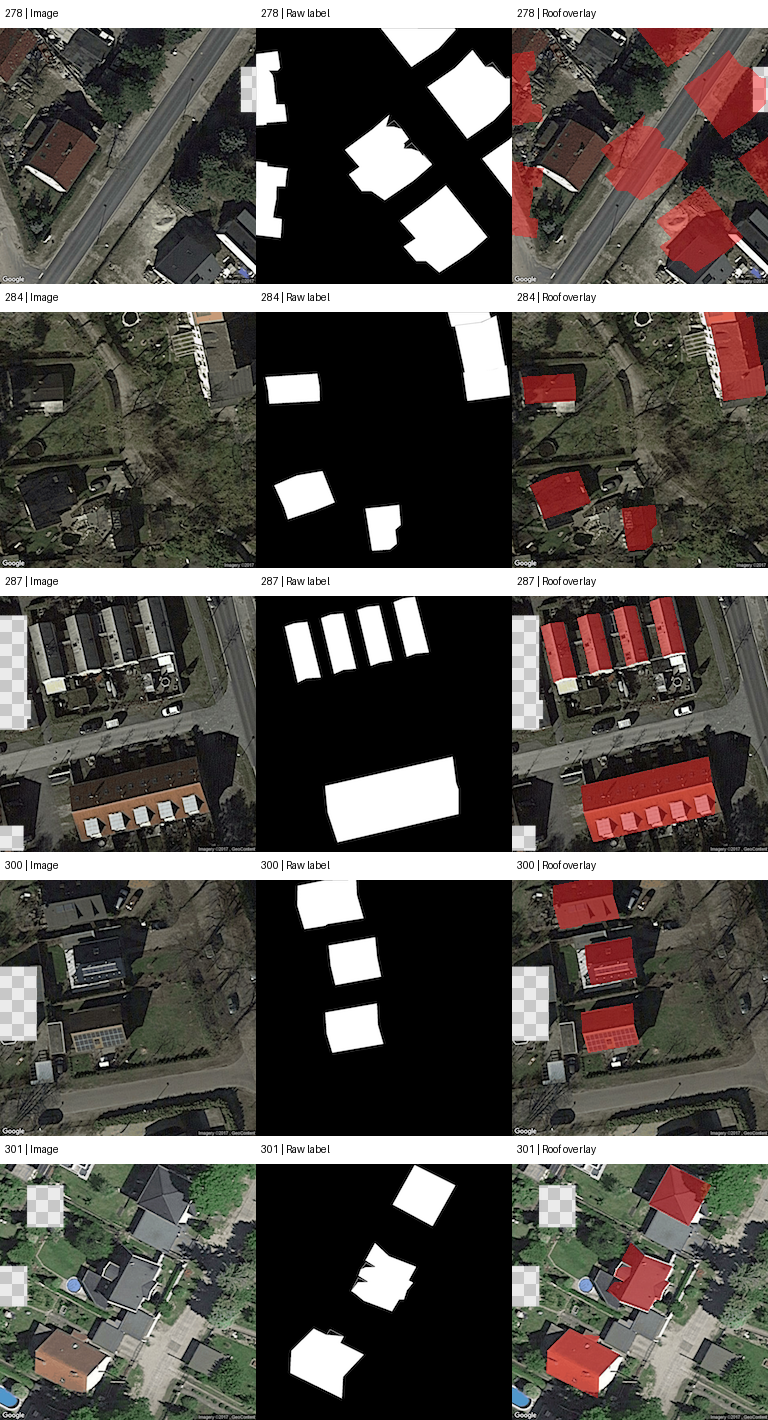

Pairs: 303, 308, 314, 315, 317


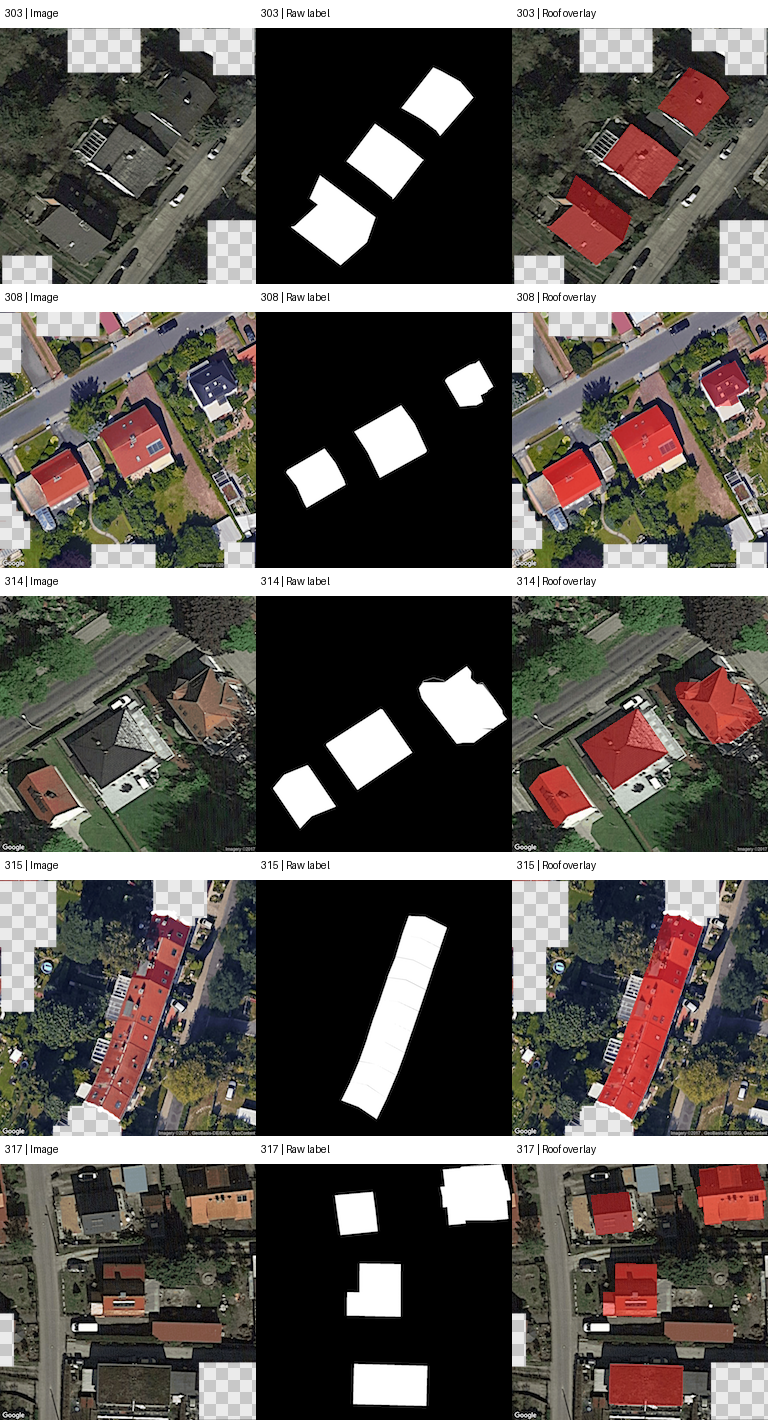

Pairs: 320, 324, 328, 337, 343


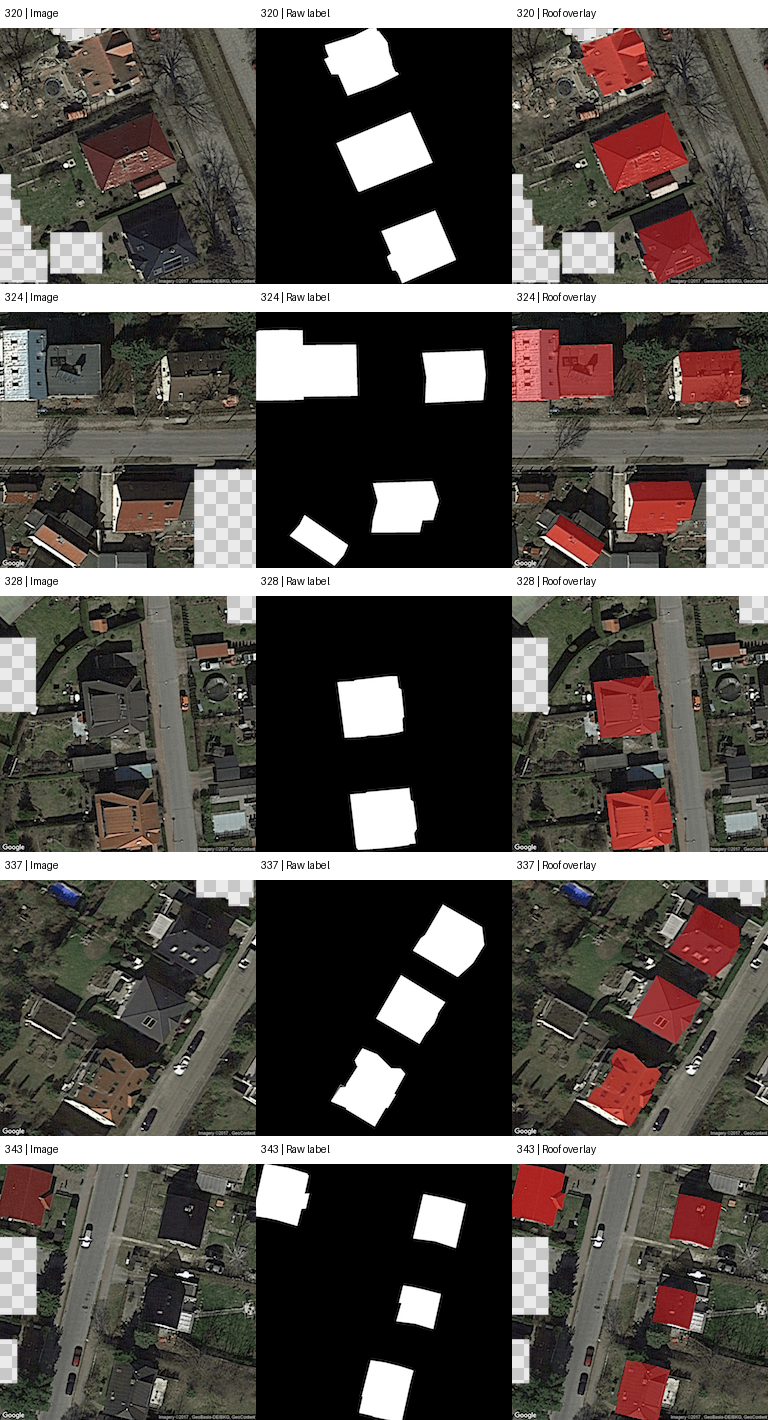

Pairs: 345, 379, 381, 417, 532


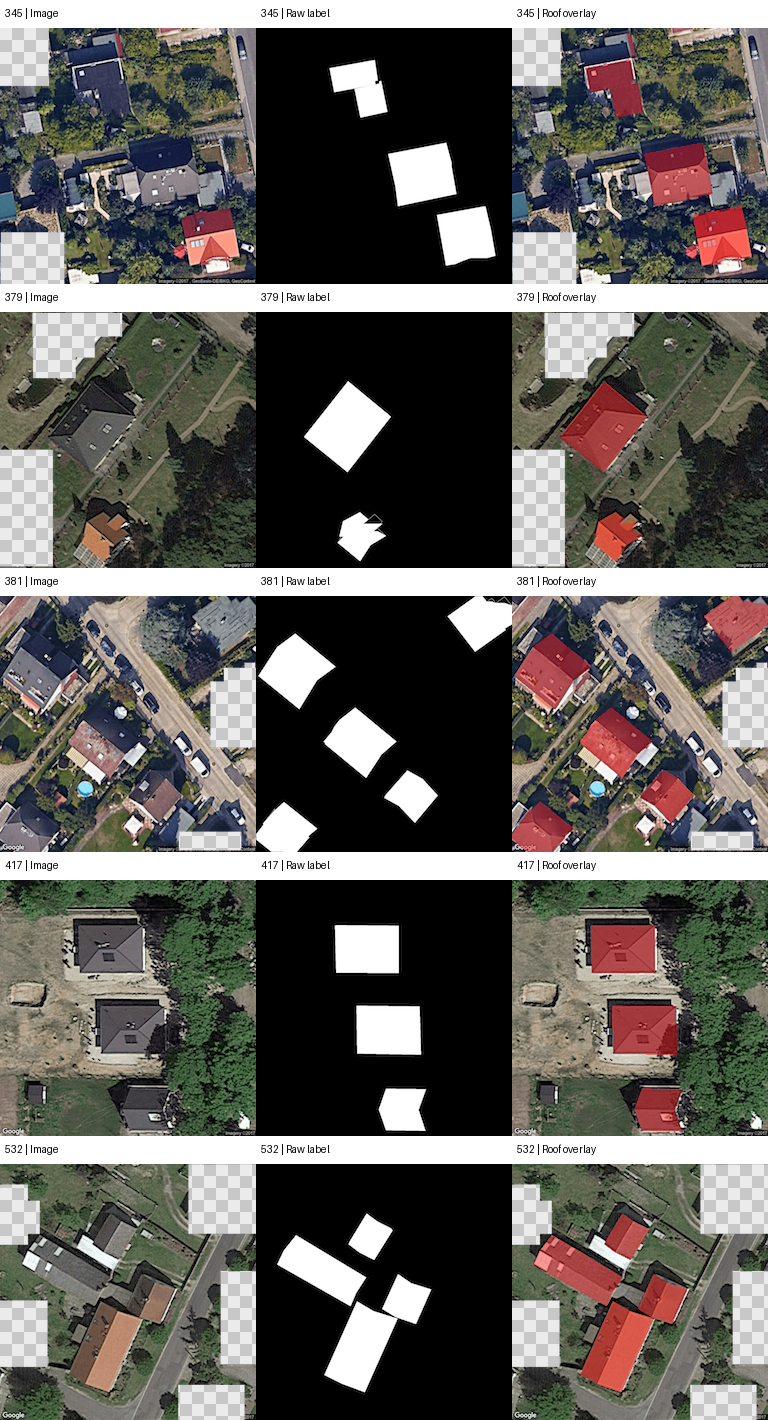

In [6]:
audit.label_gallery()


## 5 Preparation functions and provisional manifest
Keep raw data intact. The preparation function returns RGB, binary roof target, and a separate binary validity mask. The target outside valid regions is zeroed for storage only: training must still mask the loss, and evaluation must ignore invalid pixels rather than count them as correct background.

Geometric augmentation must transform all three arrays together, using nearest-neighbour interpolation for the two binary masks. Apply the pretrained encoder's normalization after these preparation steps; do not estimate global training statistics here.


In [7]:
audit.build_manifest()


Manifest counts: {'usable_labelled': 24, 'quarantined': 1, 'unlabelled': 5}
Usable labelled IDs: 121, 241, 270, 272, 274, 284, 287, 300, 301, 303, 308, 314, 315, 317, 320, 324, 328, 337, 343, 345, 379, 381, 417, 532
Quarantined: {'278': 'Label identical to 270; visual mismatch with image. Verified correction required.'}
Unlabelled prediction IDs: 535, 537, 539, 551, 553

Provisional retained dataset:
  Intermediate label pixels: 4.08%
  Roof at >=128, all pixels: 14.00%
  Roof at >0, all pixels: 16.00%
  Fully opaque valid pixels: 92.99%
  Roof among valid pixels: 15.06%
  All-background accuracy over valid pixels: 84.94%
  Roof-labelled pixels excluded by validity: 58

Preparation checks passed for all usable and unlabelled inputs.


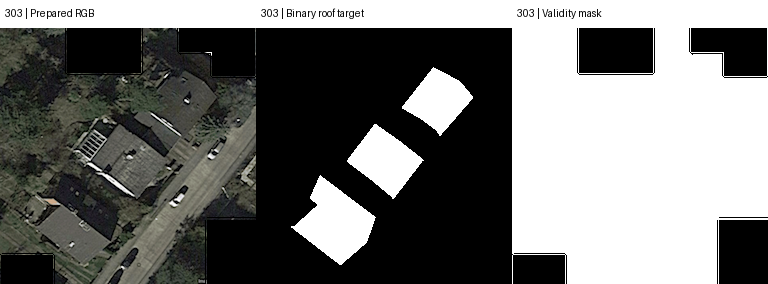

In [8]:
audit.prepared_preview()


## 6 Optional export
Export is enabled, matching the previous notebook setting. Set `EXPORT = False` for a read-only audit. The output directory comes from `PREPARED_DATA_DIR` in `.env`. It exports the manifest, audit statistics, and prepared copies for the 24 provisional labelled pairs and five unlabelled inputs. Quarantined `278` remains in the manifest and is not exported as a training pair. Original files are never changed.

Repeated exports overwrite files with the same name; use a fresh output directory if the quarantine policy changes, so obsolete prepared files cannot remain in a training directory. A future loader should always use the manifest, rather than globbing all files.


In [9]:
EXPORT = True  # Preserves original inputs and existing group/review metadata.
audit.export(enabled=EXPORT)


Prepared copies and manifest exported to /Users/zkm/Desktop/dida_test_task/data_preparation_outputs


## Decision before training

- **Quarantine 278 now**, because duplicate-mask evidence and visual misalignment agree. Do not delete it. Obtain a verified replacement annotation if possible.
- Proceed provisionally with **24 labelled pairs**. Five-fold image-level CV would have validation folds of 4–5 images, but spatial grouping takes precedence and may change the fold count.
- Resolve overlapping scenes and annotation-policy questions before interpreting validation scores. The supplied PNG files alone do not establish independent locations.
- Use thresholded masks, RGB input and a separately propagated validity mask. Use IoU/Dice over valid pixels; the measured background-only accuracy above illustrates why pixel accuracy is a poor primary metric.
- Complete the one- or two-image overfitting sanity check in the next training notebook. This audit does not demonstrate model performance.
